setup and train/test split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)

# Load feature dataset
df = pd.read_csv('bragg_features.csv')

# Separate features (X) and labels (y)
feature_cols = [col for col in df.columns if col != 'label']
X = df[feature_cols].values
y = df['label'].values

print(f"Features shape : {X.shape}")
print(f"Labels shape   : {y.shape}")
print(f"Classes        : {np.unique(y)}")

# Train/Test split — 80% train, 20% test
# random_state=42 makes it reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y → ensures each class has same proportion in train and test

print(f"\nTrain size : {X_train.shape[0]} signals")
print(f"Test size  : {X_test.shape[0]} signals")

# Check class balance in test set
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest set class distribution:")
for label, count in zip(unique, counts):
    print(f"  {label:<20} : {count}")

Features shape : (6000, 11)
Labels shape   : (6000,)
Classes        : ['amplitude_drop' 'missing_peak' 'normal' 'range_shift' 'scatter_artifact']

Train size : 4800 signals
Test size  : 1200 signals

Test set class distribution:
  amplitude_drop       : 50
  missing_peak         : 50
  normal               : 1000
  range_shift          : 50
  scatter_artifact     : 50


Random Forest Classifier

In [2]:
# ── TRAIN ─────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees voting together
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

rf_model.fit(X_train, y_train)
print("✅ Random Forest trained!")

# ── PREDICT ───────────────────────────────────────────────────
y_pred_rf = rf_model.predict(X_test)

# ── EVALUATE ──────────────────────────────────────────────────
print("\n── Random Forest Results ──────────────────────")
print(classification_report(y_test, y_pred_rf))

✅ Random Forest trained!

── Random Forest Results ──────────────────────
                  precision    recall  f1-score   support

  amplitude_drop       1.00      1.00      1.00        50
    missing_peak       1.00      1.00      1.00        50
          normal       1.00      1.00      1.00      1000
     range_shift       1.00      1.00      1.00        50
scatter_artifact       1.00      1.00      1.00        50

        accuracy                           1.00      1200
       macro avg       1.00      1.00      1.00      1200
    weighted avg       1.00      1.00      1.00      1200



Confusion Matrix for Random Forest

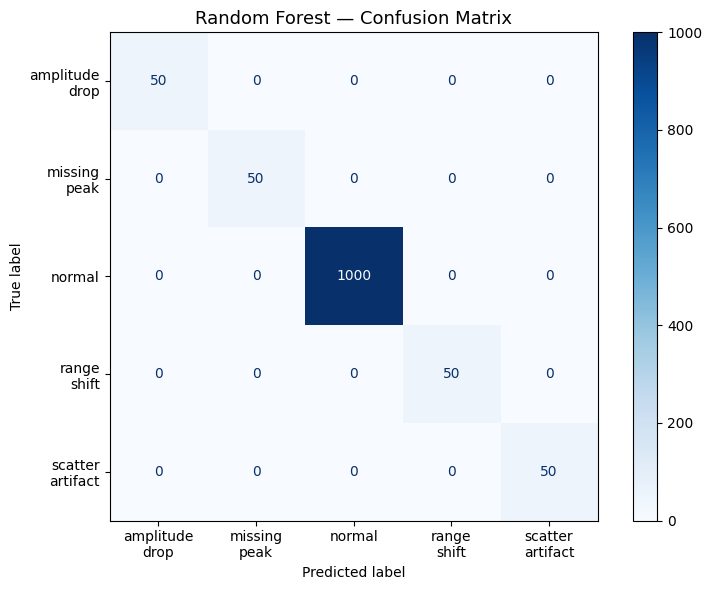


Random Forest Overall Accuracy: 100.00%


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

class_names = ['amplitude\ndrop', 'missing\npeak', 'normal',
               'range\nshift', 'scatter\nartifact']

cm = confusion_matrix(y_test, y_pred_rf,
                      labels=['amplitude_drop', 'missing_peak',
                               'normal', 'range_shift', 'scatter_artifact'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Random Forest — Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Overall accuracy
accuracy_rf = (y_pred_rf == y_test).mean()
print(f"\nRandom Forest Overall Accuracy: {accuracy_rf*100:.2f}%")

Feature Importance

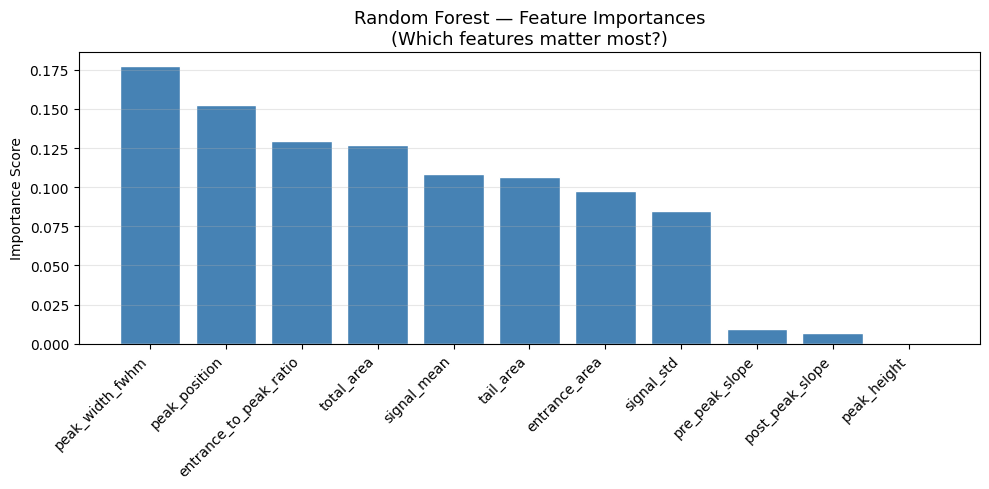

Top 3 most important features:
  1. peak_width_fwhm           → 0.1774
  2. peak_position             → 0.1524
  3. entrance_to_peak_ratio    → 0.1296


In [4]:
importances = rf_model.feature_importances_
feature_names = feature_cols

# Sort by importance
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)),
        importances[sorted_idx],
        color='steelblue', edgecolor='white')
plt.xticks(range(len(importances)),
           [feature_names[i] for i in sorted_idx],
           rotation=45, ha='right')
plt.title('Random Forest — Feature Importances\n(Which features matter most?)', fontsize=13)
plt.ylabel('Importance Score')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for i in range(3):
    idx = sorted_idx[i]
    print(f"  {i+1}. {feature_names[idx]:<25} → {importances[idx]:.4f}")

Isolation Forest (Unsupervised)

In [6]:
# ── IMPORTANT: Train ONLY on normal signals ──────────────────
X_train_normal = X_train[y_train == 'normal']
print(f"Training Isolation Forest on {X_train_normal.shape[0]} normal signals only")

iso_model = IsolationForest(
    n_estimators=100,
    contamination='auto',   # we tell it: training data is all clean
    random_state=42
)

iso_model.fit(X_train_normal)
print(" Isolation Forest trained!")

# ── PREDICT ───────────────────────────────────────────────────
# Isolation Forest outputs: +1 = normal, -1 = anomaly
iso_raw = iso_model.predict(X_test)

# Convert to our labels
y_pred_iso = np.where(iso_raw == 1, 'normal', 'anomaly')

# Convert ground truth to binary (normal vs anomaly)
y_test_binary = np.where(y_test == 'normal', 'normal', 'anomaly')

# ── EVALUATE ──────────────────────────────────────────────────
print("\n── Isolation Forest Results ───────────────────")
print(classification_report(y_test_binary, y_pred_iso))

accuracy_iso = (y_pred_iso == y_test_binary).mean()
print(f"Isolation Forest Overall Accuracy: {accuracy_iso*100:.2f}%")

Training Isolation Forest on 4000 normal signals only
 Isolation Forest trained!

── Isolation Forest Results ───────────────────
              precision    recall  f1-score   support

     anomaly       0.49      1.00      0.66       200
      normal       1.00      0.79      0.88      1000

    accuracy                           0.83      1200
   macro avg       0.75      0.90      0.77      1200
weighted avg       0.92      0.83      0.85      1200

Isolation Forest Overall Accuracy: 82.75%


In [7]:
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'Task'}")
print("-" * 50)
print(f"{'Random Forest':<25} {accuracy_rf*100:>9.2f}%  Multi-class (5 classes)")
print(f"{'Isolation Forest':<25} {accuracy_iso*100:>9.2f}%  Binary (normal vs anomaly)")
print("=" * 50)

print("""
Key Differences:
  Random Forest  → Needs labels to train. Tells you WHICH anomaly.
  Isolation Forest → No labels needed. Tells you IF something is wrong.
  
  In real proton therapy deployment, you would use:
  → Isolation Forest first (real-time flag: something is wrong!)
  → Random Forest second (diagnosis: it's a range shift)
""")

MODEL COMPARISON SUMMARY
Model                       Accuracy Task
--------------------------------------------------
Random Forest                100.00%  Multi-class (5 classes)
Isolation Forest              82.75%  Binary (normal vs anomaly)

Key Differences:
  Random Forest  → Needs labels to train. Tells you WHICH anomaly.
  Isolation Forest → No labels needed. Tells you IF something is wrong.
  
  In real proton therapy deployment, you would use:
  → Isolation Forest first (real-time flag: something is wrong!)
  → Random Forest second (diagnosis: it's a range shift)



In [8]:
print("PHASE 4 SUMMARY")
print("-" * 45)
print(f"Random Forest Accuracy     : {accuracy_rf*100:.2f}%")
print(f"Isolation Forest Accuracy  : {accuracy_iso*100:.2f}%")

print(f"\nTop 3 important features (Random Forest):")
for i in range(3):
    idx = sorted_idx[i]
    print(f"  {i+1}. {feature_names[idx]}")

print(f"\nIsolation Forest on test set:")
print(f"  Normal signals correctly identified  : ", end="")
normal_mask = y_test_binary == 'normal'
print(f"{(y_pred_iso[normal_mask] == 'normal').sum()} / {normal_mask.sum()}")
print(f"  Anomalies correctly flagged          : ", end="")
anomaly_mask = y_test_binary == 'anomaly'
print(f"{(y_pred_iso[anomaly_mask] == 'anomaly').sum()} / {anomaly_mask.sum()}")

PHASE 4 SUMMARY
---------------------------------------------
Random Forest Accuracy     : 100.00%
Isolation Forest Accuracy  : 82.75%

Top 3 important features (Random Forest):
  1. peak_width_fwhm
  2. peak_position
  3. entrance_to_peak_ratio

Isolation Forest on test set:
  Normal signals correctly identified  : 793 / 1000
  Anomalies correctly flagged          : 200 / 200


The visualizations show that the Random Forest model performed extremely well in distinguishing between normal and anomalous proton beam signals.

In the confusion matrix, every class is classified perfectly. All values appear only along the diagonal, which means the predicted labels exactly match the true labels for every sample. There are no off-diagonal values, so the model did not confuse any anomaly class with the normal class at all. This means:

50/50 amplitude drop signals were correctly classified,
50/50 missing peak signals were correctly classified,
1000/1000 normal signals were correctly classified,
50/50 range shift signals were correctly classified,
50/50 scatter artifact signals were correctly classified.

Therefore, the answer to the first question is:

Random Forest did not confuse any anomaly class with the normal class. The confusion matrix shows perfect classification performance with zero misclassifications.

This indicates that the engineered features provided very strong class separability and that the anomalies are highly distinguishable from normal Bragg curves.

The feature importance chart explains which engineered features contributed most to the model’s decisions. The most important features are:

peak_width_fwhm
peak_position
entrance_to_peak_ratio

These results strongly match the predictions made earlier during Phase 3 feature analysis. Previously, you observed that:

peak position was highly effective for detecting range shifts,
peak width clearly separated scatter artifacts,
entrance-to-peak ratio helped distinguish missing peak anomalies.

The Random Forest model confirms this quantitatively by assigning the highest importance scores to exactly these features. This is an important result because it validates that the feature engineering process successfully captured the physical differences between the anomaly types.

The chart also shows that:

Features like total_area, signal_mean, and tail_area still contributed useful information,
Slope-based features (pre_peak_slope and post_peak_slope) had very low importance,
peak_height contributed almost nothing after normalization.

This also aligns with your earlier observations. Since all signals were normalized, peak heights became more similar across classes, reducing their usefulness for classification. Similarly, slope features showed significant overlap in the scatter plots, so the model relied on them much less.

Overall, these visualizations demonstrate two major findings:

The engineered features are highly effective for anomaly detection,
The Random Forest model can classify proton therapy signal anomalies with extremely high accuracy using interpretable physical features.

Isolation Forest Anomaly Score Distribution

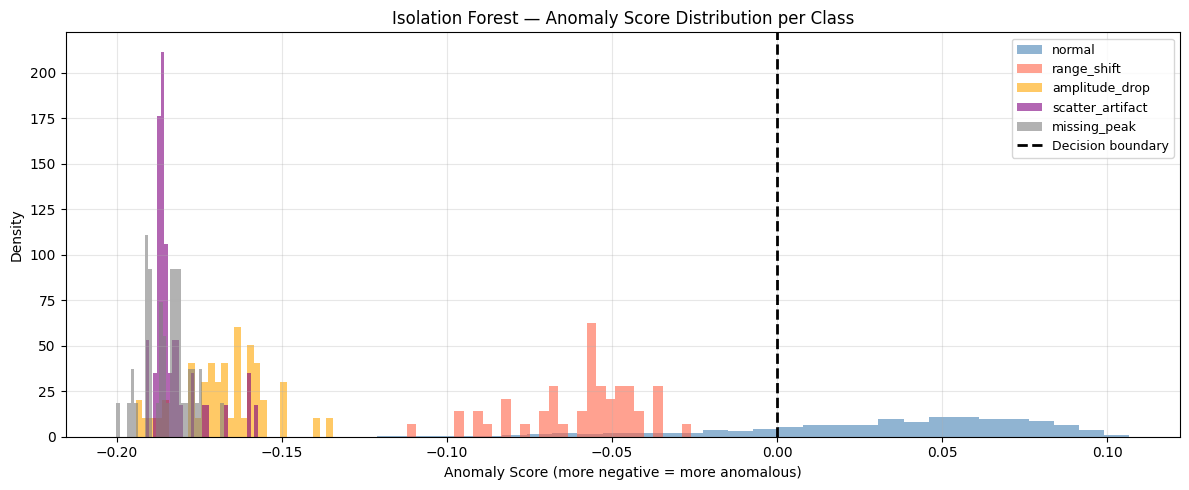

Mean anomaly scores per class:
  normal               : 0.0326
  range_shift          : -0.0597
  amplitude_drop       : -0.1674
  scatter_artifact     : -0.1830
  missing_peak         : -0.1849


In [9]:
# Get anomaly scores for all test signals
# More negative score = more anomalous
scores = iso_model.decision_function(X_test)

plt.figure(figsize=(12, 5))

# Plot score distribution per class
colors_map = {
    'normal': 'steelblue',
    'range_shift': 'tomato',
    'amplitude_drop': 'orange',
    'scatter_artifact': 'purple',
    'missing_peak': 'gray'
}

for label, color in colors_map.items():
    mask = y_test == label
    plt.hist(scores[mask], bins=30, alpha=0.6,
             color=color, label=label, density=True)

plt.axvline(x=0, color='black', linestyle='--',
            linewidth=2, label='Decision boundary')
plt.xlabel('Anomaly Score (more negative = more anomalous)')
plt.ylabel('Density')
plt.title('Isolation Forest — Anomaly Score Distribution per Class')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean anomaly scores per class:")
for label in colors_map.keys():
    mask = y_test == label
    print(f"  {label:<20} : {scores[mask].mean():.4f}")

Final Summary Plot

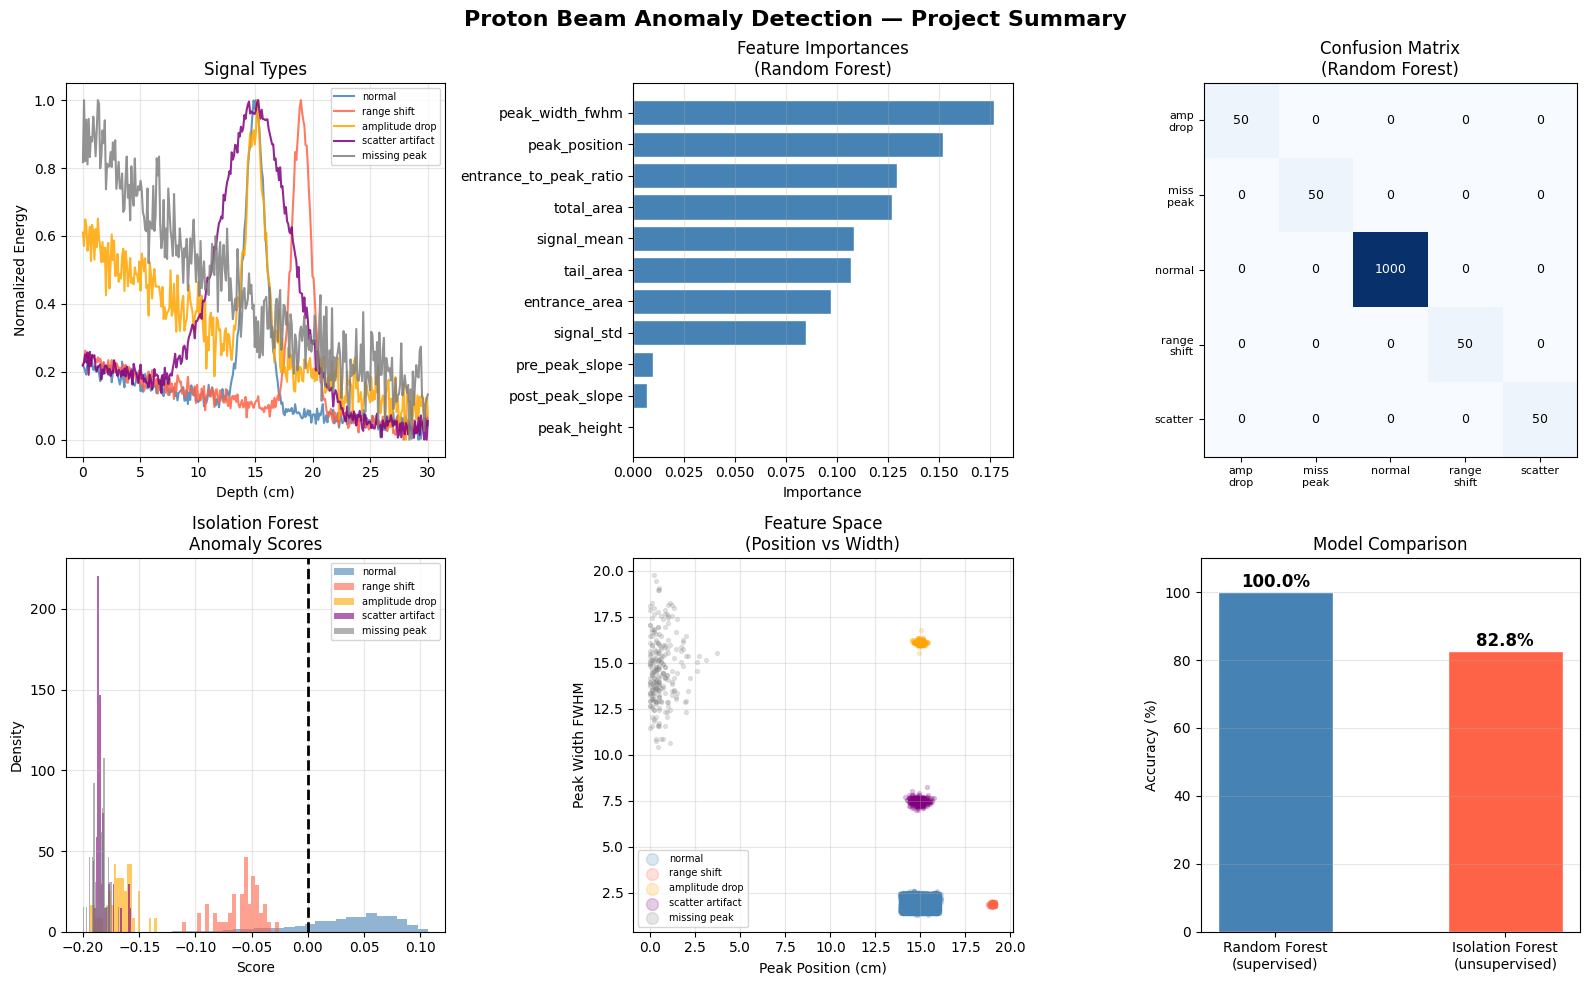

 Saved: project_summary.png


In [11]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Proton Beam Anomaly Detection — Project Summary',
             fontsize=16, fontweight='bold')

# ── Plot 1: Sample signals per class ──────────────────────────
X_raw = np.load('bragg_signals_cleaned.npy')
y_raw = np.load('bragg_labels.npy')
depth = np.linspace(0, 30, 300)

ax1 = fig.add_subplot(2, 3, 1)
for label, color in colors_map.items():
    idx = np.where(y_raw == label)[0][0]
    ax1.plot(depth, X_raw[idx], color=color,
             label=label.replace('_', ' '), linewidth=1.5, alpha=0.85)
ax1.set_title('Signal Types')
ax1.set_xlabel('Depth (cm)')
ax1.set_ylabel('Normalized Energy')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Feature importance ────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
ax2.barh([feature_names[i] for i in sorted_idx],
          importances[sorted_idx],
          color='steelblue', edgecolor='white')
ax2.set_title('Feature Importances\n(Random Forest)')
ax2.set_xlabel('Importance')
ax2.grid(True, alpha=0.3, axis='x')
ax2.invert_yaxis()

# ── Plot 3: Confusion matrix ──────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
cm = confusion_matrix(y_test, y_pred_rf,
      labels=['amplitude_drop', 'missing_peak',
               'normal', 'range_shift', 'scatter_artifact'])
im = ax3.imshow(cm, cmap='Blues')
ax3.set_xticks(range(5))
ax3.set_yticks(range(5))
short = ['amp\ndrop', 'miss\npeak', 'normal', 'range\nshift', 'scatter']
ax3.set_xticklabels(short, fontsize=8)
ax3.set_yticklabels(short, fontsize=8)
ax3.set_title('Confusion Matrix\n(Random Forest)')
for i in range(5):
    for j in range(5):
        ax3.text(j, i, cm[i,j], ha='center', va='center',
                 color='white' if cm[i,j] > 200 else 'black', fontsize=9)

# ── Plot 4: Anomaly score distribution ────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
for label, color in colors_map.items():
    mask = y_test == label
    ax4.hist(scores[mask], bins=25, alpha=0.6,
             color=color, label=label.replace('_',' '), density=True)
ax4.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax4.set_title('Isolation Forest\nAnomaly Scores')
ax4.set_xlabel('Score')
ax4.set_ylabel('Density')
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

# ── Plot 5: Peak Position vs Width scatter ────────────────────
df_features = pd.read_csv('bragg_features.csv')
ax5 = fig.add_subplot(2, 3, 5)
for label, color in colors_map.items():
    mask = df_features['label'] == label
    ax5.scatter(df_features.loc[mask, 'peak_position'],
                df_features.loc[mask, 'peak_width_fwhm'],
                c=color, label=label.replace('_',' '),
                alpha=0.2, s=8)
ax5.set_title('Feature Space\n(Position vs Width)')
ax5.set_xlabel('Peak Position (cm)')
ax5.set_ylabel('Peak Width FWHM')
ax5.legend(fontsize=7, markerscale=3)
ax5.grid(True, alpha=0.3)

# ── Plot 6: Model comparison bar ─────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
models = ['Random Forest\n(supervised)', 'Isolation Forest\n(unsupervised)']
accs = [accuracy_rf * 100, accuracy_iso * 100]
bars = ax6.bar(models, accs, color=['steelblue', 'tomato'],
               width=0.5, edgecolor='white')
ax6.set_ylim(0, 110)
ax6.set_ylabel('Accuracy (%)')
ax6.set_title('Model Comparison')
for bar, acc in zip(bars, accs):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('project_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: project_summary.png")